# Part III – Sentiment Analysis using RNN, LSTM, and Word2Vec Embeddings
## 6CS012 – Final Integrated Assessment | Herald College, Kathmandu

**Dataset:** Financial PhraseBank – Polar Sentiment Dataset  
**Task:** Text Classification (Positive / Neutral / Negative)  
**Models:** Simple RNN | LSTM with Trainable Embeddings | LSTM with Pretrained Word2Vec  

---

## ✅ CELL 0 – Google Colab GPU Setup & Drive Mount
**Purpose:** Enable T4 GPU and mount Google Drive for saving model checkpoints.  
Run this cell first on Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory ready: {CHECKPOINT_DIR}')


import tensorflow as tf
print('GPU Available:', tf.config.list_physical_devices('GPU'))
print('TensorFlow version:', tf.__version__)

Mounted at /content/drive
Checkpoint directory ready: /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


 Install Required Libraries


In [ ]:
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install contractions -q
!pip install wordcloud -q
!pip install nltk -q


print('All packages installed. Restart runtime if prompted.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 86.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00
All packages installed. Restart runtime if prompted.


 Import All Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

print('All libraries imported successfully.')

All libraries imported successfully.


 Load Dataset


In [ ]:
# Load the CSV from Google Drive
import os
import pandas as pd

# Construct the full path to the CSV file
CSV_PATH = os.path.join(CHECKPOINT_DIR, 'financial_phrase.csv')

# Load from the specified Drive path
df = pd.read_csv(CSV_PATH)

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nNull Values:')
print(df.isnull().sum())
print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (2264, 2)

Column Names: ['text', 'label']

Data Types:
text     object
label    object
dtype: object

Null Values:
text     0
label    0
dtype: int64

First 5 Rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


 Exploratory Data Analysis (EDA)


Label Distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


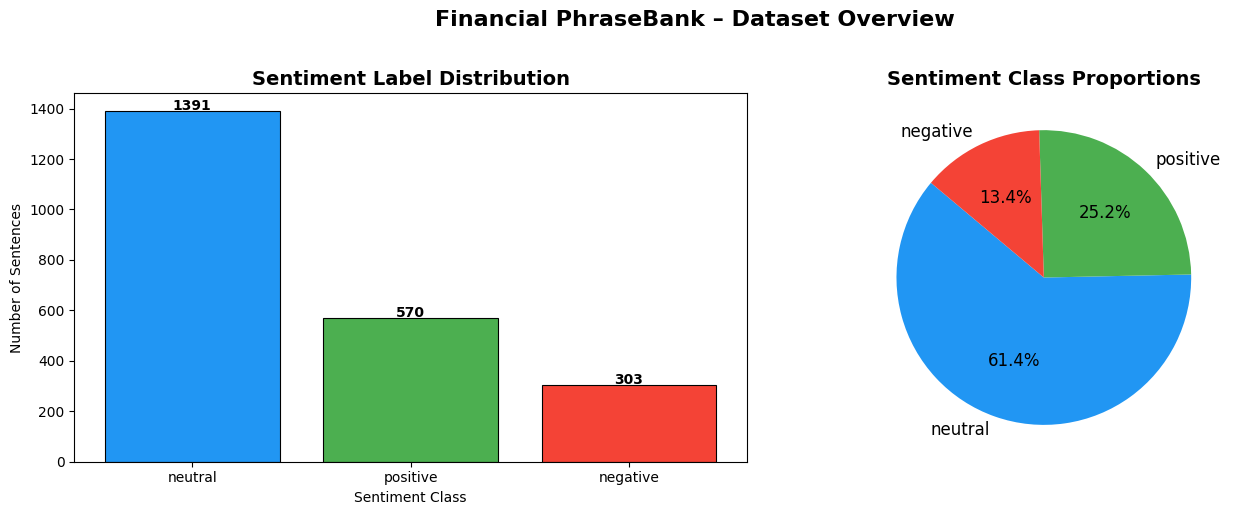


Text Length Statistics (in words):
count    2264.000000
mean       22.441696
std        10.147048
min         2.000000
25%        15.000000
50%        21.000000
75%        28.000000
max        81.000000
Name: text_length, dtype: float64


In [ ]:
label_counts = df['label'].value_counts()
print('Label Distribution:')
print(label_counts)

#Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Bar Chart
colors = ['#2196F3', '#4CAF50', '#F44336']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Sentences')
for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

#Pie Chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Class Proportions', fontsize=14, fontweight='bold')

plt.suptitle('Financial PhraseBank – Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Text Length Analysis
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
print('\nText Length Statistics (in words):')
print(df['text_length'].describe())

 Text Preprocessing


In [ ]:
# Initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Full NLP cleaning pipeline for financial text.
    Steps: lowercase → expand contractions → remove noise → lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand contractions (e.g., "don't" → "do not")
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 4: Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Step 5: Remove hashtags (#topic)
    text = re.sub(r'#\w+', '', text)

    # Step 6: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 7: Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 8: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 9: Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 1]

    return ' '.join(tokens)

# Apply cleaning pipeline
print('Cleaning text... (this may take a moment)')
df['cleaned_text'] = df['text'].apply(clean_text)

# Show before/after comparison
print('\n--- Before vs After Cleaning ---')
for i in range(3):
    print(f'\n[{i+1}] Original : {df["text"].iloc[i]}')
    print(f'    Cleaned  : {df["cleaned_text"].iloc[i]}')
    print(f'    Label    : {df["label"].iloc[i]}')

print('\nCleaning complete.')

Cleaning text... (this may take a moment)

--- Before vs After Cleaning ---

[1] Original : According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
    Cleaned  : according gran company plan move production russia although company growing
    Label    : neutral

[2] Original : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
    Cleaned  : last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit pretax loss eurm
    Label    : positive

[3] Original : In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .
    Cleaned  : third quarter net sale increased eur mn operating profit eur mn
    Label    : positive

Cleaning complete.


 Word Cloud Visualization


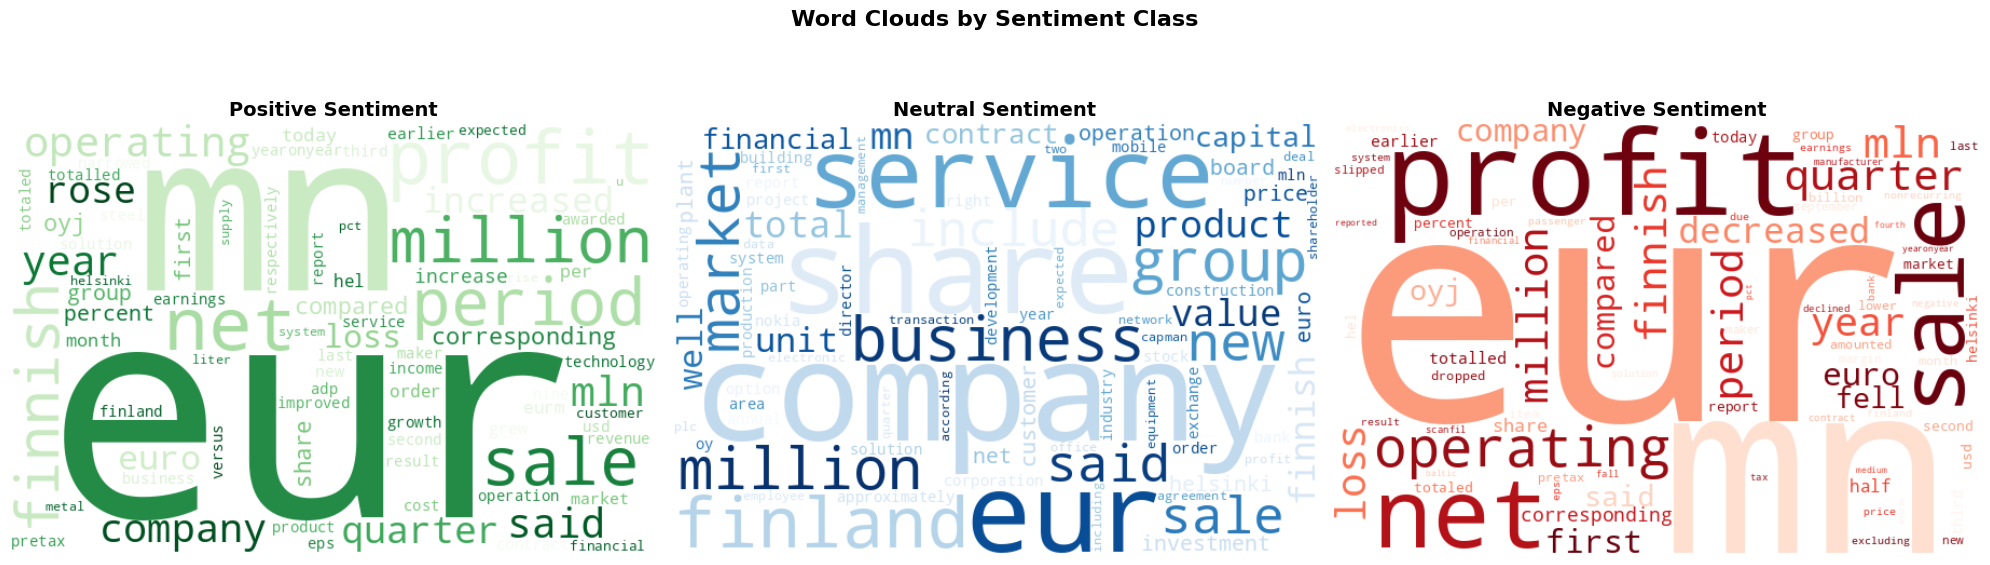

In [ ]:
#  Word Cloud per Sentiment Class
sentiments = ['positive', 'neutral', 'negative']
wc_colors = ['Greens', 'Blues', 'Reds']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (sentiment, colormap) in enumerate(zip(sentiments, wc_colors)):
    text_data = ' '.join(df[df['label'] == sentiment]['cleaned_text'])
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap,
        max_words=80,
        collocations=False
    ).generate(text_data)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{sentiment.capitalize()} Sentiment', fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

 Most Frequent Words Bar Chart


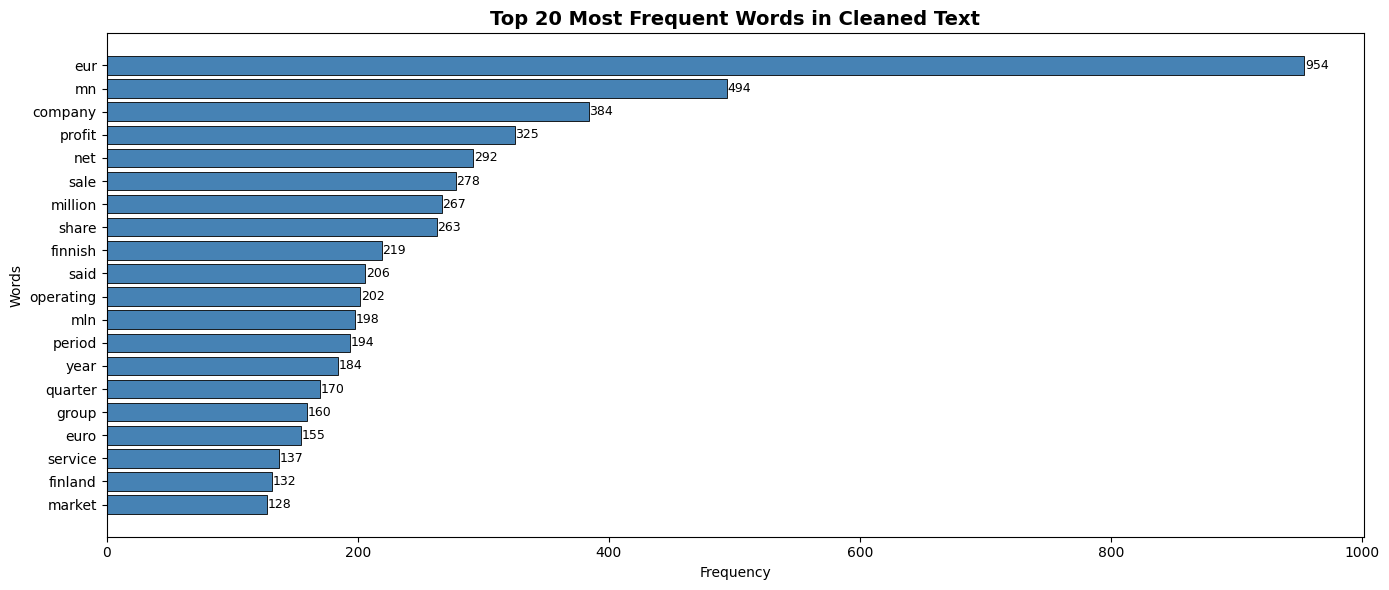

In [ ]:
#  Top 20 Most Frequent Words
all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(14, 6))
bars = plt.barh(words[::-1], freqs[::-1], color='steelblue', edgecolor='black', linewidth=0.6)
plt.title('Top 20 Most Frequent Words in Cleaned Text', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
for bar, freq in zip(bars, freqs[::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(freq), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

 Label Encoding & Train/Test Split


In [ ]:
#  Label Encoding
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print('Label Mapping:')
for cls, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f'  {idx} → {cls}')

NUM_CLASSES = len(label_encoder.classes_)
print(f'\nTotal classes: {NUM_CLASSES}')

#  Train / Test Split (80:20)
X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Label Mapping:
  0 → negative
  1 → neutral
  2 → positive

Total classes: 3
Class weights: {0: np.float64(2.494490358126722), 1: np.float64(0.5423779574722971), 2: np.float64(1.3238304093567252)}


 Tokenization and Sequence Padding


In [ ]:
#  Keras Tokenizer
MAX_VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Total unique words in corpus: {len(tokenizer.word_index)}')

#  Convert Text to Integer Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

seq_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 99))
print(f'\nSequence length stats (training):')
print(f'  Min: {min(seq_lengths)}, Max: {max(seq_lengths)}')
print(f'  Mean: {np.mean(seq_lengths):.1f}, Median: {np.median(seq_lengths):.1f}')
print(f'  99th Percentile (MAX_LEN): {MAX_LEN}')

# Apply padding (post-padding, post-truncation)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape : {X_test_pad.shape}')

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'y_train_cat shape: {y_train_cat.shape}')


Vocabulary size : 4397
Total unique words in corpus: 4396

Sequence length stats (training):
  Min: 1, Max: 36
  Mean: 11.4, Median: 10.0
  99th Percentile (MAX_LEN): 26

X_train_pad shape: (1811, 26)
X_test_pad shape : (453, 26)
y_train_cat shape: (1811, 3)


Callbacks


In [ ]:
#  Reusable callback factory
def get_callbacks(model_name, checkpoint_dir=CHECKPOINT_DIR):
    """
    Returns EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint callbacks.
    """
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, f'{model_name}_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    return [early_stop, reduce_lr, checkpoint]

print('Callbacks defined.')


Callbacks defined.


 Model 1: Simple RNN with Trainable Embedding

In [ ]:
#  Model 1: Simple RNN
EMBEDDING_DIM = 128

model1 = Sequential(name='SimpleRNN_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,
              name='embedding_rnn'),

    # SimpleRNN with more units to capture more patterns
    SimpleRNN(units=128, activation='tanh', return_sequences=False, name='simple_rnn'),

    BatchNormalization(name='bn_rnn'),

    Dropout(0.4, name='dropout_rnn'),

    Dense(64, activation='relu', name='dense_hidden_rnn'),
    Dropout(0.3, name='dropout_dense_rnn'),

    Dense(NUM_CLASSES, activation='softmax', name='output_rnn')
])

model1.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model1.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_rnn (BatchNormalization)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_rnn (Dropout)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_rnn (Dense)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense_rnn (Dropout)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_rnn (Dense)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train Model 1
print('Training Model 1 – Simple RNN...')
start_time = time.time()

history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=get_callbacks('model1_SimpleRNN'),
    class_weight=class_weight_dict,
    verbose=1
)

model1_time = time.time() - start_time
print(f'\nModel 1 training time: {model1_time:.2f} seconds')

Training Model 1 – Simple RNN...
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2976 - loss: 1.7258
Epoch 1: val_accuracy improved from None to 0.61029, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.4055 - loss: 1.4184 - val_accuracy: 0.6103 - val_loss: 0.9360 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6707 - loss: 0.8876
Epoch 2: val_accuracy did not improve from 0.61029
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6764 - loss: 0.8362 - val_accuracy: 0.6103 - val_loss: 1.0702 - learning_rate: 0.0010
Epoch 3/30
40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7766 - loss: 0.6881
Epoch 3: val_accuracy did not improve from 0.61029
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7745 - loss: 0.6579 - val_accuracy: 0.6103 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8376 - loss: 0.5103
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did


Epoch 5: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9214 - loss: 0.2631 - val_accuracy: 0.6397 - val_loss: 1.2357 - learning_rate: 5.0000e-04
Epoch 6/30
45/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9382 - loss: 0.2069
Epoch 6: val_accuracy did not improve from 0.63971
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9545 - loss: 0.1725 - val_accuracy: 0.5184 - val_loss: 1.0601 - learning_rate: 5.0000e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9635 - loss: 0.1202
Epoch 7: val_accuracy improved from 0.63971 to 0.75735, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9669 - loss: 0.1120 - val_accuracy: 0.7574 - val_loss: 0.5952 - learning_rate: 5.0000e-04
Epoch 8/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9800 - loss: 0.0775
Epoch 8: val_accuracy improved from 0.75735 to 0.76103, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5



Epoch 8: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model1_SimpleRNN_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9818 - loss: 0.0771 - val_accuracy: 0.7610 - val_loss: 0.8357 - learning_rate: 5.0000e-04
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9866 - loss: 0.0584
Epoch 9: val_accuracy did not improve from 0.76103
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9838 - loss: 0.0633 - val_accuracy: 0.7353 - val_loss: 1.1177 - learning_rate: 5.0000e-04
Epoch 10/30
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9873 - loss: 0.0532
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_accuracy did not improve from 0.76103
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9857 - loss: 0.0565 - val_accuracy: 0.6838 - val_loss: 0.8892 - learning_rate: 5.0000e-04
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9883 - loss: 0.0465
Epoch 11:

 Model 2: LSTM with Trainable Embedding


In [ ]:
#  Model 2: LSTM with Trainable Embeddings
from tensorflow.keras.layers import Bidirectional

model2 = Sequential(name='LSTM_TrainableEmbedding', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,
              name='embedding_lstm'),

    Bidirectional(LSTM(units=128, dropout=0.2, recurrent_dropout=0.2,
                       return_sequences=False), name='bilstm_layer'),

    BatchNormalization(name='bn_lstm'),

    Dropout(0.4, name='dropout_lstm'),

    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.3, name='dropout_dense'),

    Dense(NUM_CLASSES, activation='softmax', name='output_lstm')
])

model2.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model2.summary()


Model: "LSTM_TrainableEmbedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_layer (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_lstm (BatchNormalization)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm (Dropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_lstm (Dense)             │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train Model 2
print('Training Model 2 – LSTM with Trainable Embeddings...')
start_time = time.time()

history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=get_callbacks('model2_LSTM'),
    class_weight=class_weight_dict,   # ← ADD THIS LINE
    verbose=1
)

model2_time = time.time() - start_time
print(f'\nModel 2 training time: {model2_time:.2f} seconds')

Training Model 2 – LSTM with Trainable Embeddings...
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4485 - loss: 1.1186
Epoch 1: val_accuracy improved from None to 0.47059, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - accuracy: 0.5029 - loss: 1.0520 - val_accuracy: 0.4706 - val_loss: 1.0761 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7182 - loss: 0.7578
Epoch 2: val_accuracy improved from 0.47059 to 0.74632, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.7524 - loss: 0.7018 - val_accuracy: 0.7463 - val_loss: 0.9447 - learning_rate: 0.0010
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8719 - loss: 0.3735
Epoch 3: val_accuracy improved from 0.74632 to 0.83456, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model2_LSTM_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.8863 - loss: 0.3444 - val_accuracy: 0.8346 - val_loss: 0.8300 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9353 - loss: 0.2000
Epoch 4: val_accuracy did not improve from 0.83456
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.9318 - loss: 0.1952 - val_accuracy: 0.7904 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9497 - loss: 0.1539
Epoch 5: val_accuracy did not improve from 0.83456
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.9500 - loss: 0.1534 - val_accuracy: 0.7096 - val_loss: 0.6534 - learning_rate: 0.0010
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9605 - loss: 0.1198
Epoch 6: val_accuracy did not improve from 0.83456
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - 

Load Pretrained Word2Vec (GloVe) Embeddings


In [ ]:
import gensim.downloader as api

print('Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...')
print('This will download ~66MB — please wait...')

embedding_model = api.load('glove-twitter-50')
PRETRAINED_DIM = 50

print(f'\nEmbedding model loaded. Vector dimension: {PRETRAINED_DIM}')
print(f'Total vocabulary in GloVe model: {len(embedding_model.key_to_index)}')

#  Build Embedding Matrix
embedding_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_DIM))

found_count = 0
not_found = []

for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found_count += 1
        else:
            not_found.append(word)

print(f'\nWords found in GloVe   : {found_count}')
print(f'Words NOT found in GloVe: {len(not_found)}')
print(f'Coverage               : {found_count / VOCAB_SIZE * 100:.1f}%')
print(f'Embedding matrix shape : {embedding_matrix.shape}')

Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...
This will download ~66MB — please wait...
[==================================================] 100.0% 199.5/199.5MB downloaded

Embedding model loaded. Vector dimension: 50
Total vocabulary in GloVe model: 1193514

Words found in GloVe   : 3628
Words NOT found in GloVe: 768
Coverage               : 82.5%
Embedding matrix shape : (4397, 50)


 Model 3: Bidirectional LSTM with Pretrained GloVe Embeddings


In [ ]:
#  Model 3: Bidirectional LSTM with Pretrained GloVe Embeddings
from tensorflow.keras.layers import Bidirectional

model3 = Sequential(name='BiLSTM_GloVe', layers=[
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=PRETRAINED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
        name='glove_embedding'
    ),

    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2,
                       return_sequences=True), name='bilstm_1'),

    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2,
                       return_sequences=False), name='bilstm_2'),

    BatchNormalization(name='batch_norm'),
    Dropout(0.4, name='dropout_1'),

    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.3, name='dropout_2'),

    Dense(NUM_CLASSES, activation='softmax', name='output_layer')
])

model3.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model3.summary()


Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       219,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,850 (858.79 KB)

 Trainable params: 219,850 (858.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train Model 3
print('Training Model 3 – LSTM with Pretrained GloVe Embeddings...')
start_time = time.time()

history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=get_callbacks('model3_LSTM_GloVe'),
    class_weight=class_weight_dict,
    verbose=1
)

model3_time = time.time() - start_time
print(f'\nModel 3 training time: {model3_time:.2f} seconds')

Training Model 3 – LSTM with Pretrained GloVe Embeddings...
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.4184 - loss: 1.4790
Epoch 1: val_accuracy improved from None to 0.52941, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 32s 400ms/step - accuracy: 0.4561 - loss: 1.3656 - val_accuracy: 0.5294 - val_loss: 1.0554 - learning_rate: 5.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5247 - loss: 1.2091
Epoch 2: val_accuracy improved from 0.52941 to 0.59191, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 388ms/step - accuracy: 0.5231 - loss: 1.2456 - val_accuracy: 0.5919 - val_loss: 0.9925 - learning_rate: 5.0000e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5721 - loss: 1.1046
Epoch 3: val_accuracy improved from 0.59191 to 0.64338, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 384ms/step - accuracy: 0.5679 - loss: 1.1403 - val_accuracy: 0.6434 - val_loss: 0.9419 - learning_rate: 5.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5906 - loss: 1.0298
Epoch 4: val_accuracy did not improve from 0.64338
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - accuracy: 0.5763 - loss: 1.0886 - val_accuracy: 0.6397 - val_loss: 0.9545 - learning_rate: 5.0000e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.5733 - loss: 1.0497
Epoch 5: val_accuracy did not improve from 0.64338
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - accuracy: 0.5867 - loss: 1.0285 - val_accuracy: 0.6066 - val_loss: 0.8949 - learning_rate: 5.0000e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6085 - loss: 1.0128
Epoch 6: val_accuracy did not improve from 0.64338
49/49 ━━━━━━━━━━━━━━━━━━━


Epoch 7: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 394ms/step - accuracy: 0.6381 - loss: 0.8853 - val_accuracy: 0.6801 - val_loss: 0.7174 - learning_rate: 5.0000e-04
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6424 - loss: 0.8820
Epoch 8: val_accuracy improved from 0.68015 to 0.69485, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5


...


Epoch 14: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 378ms/step - accuracy: 0.7290 - loss: 0.6939 - val_accuracy: 0.7353 - val_loss: 0.5987 - learning_rate: 5.0000e-04
Epoch 15/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7280 - loss: 0.6233
Epoch 15: val_accuracy did not improve from 0.73529
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 385ms/step - accuracy: 0.7290 - loss: 0.6633 - val_accuracy: 0.7206 - val_loss: 0.6442 - learning_rate: 5.0000e-04
Epoch 16/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7315 - loss: 0.6783
Epoch 16: val_accuracy improved from 0.73529 to 0.75368, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 16: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 382ms/step - accuracy: 0.7414 - loss: 0.6538 - val_accuracy: 0.7537 - val_loss: 0.6124 - learning_rate: 5.0000e-04
Epoch 17/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.7780 - loss: 0.5818
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: val_accuracy did not improve from 0.75368
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 372ms/step - accuracy: 0.7752 - loss: 0.6059 - val_accuracy: 0.7279 - val_loss: 0.6436 - learning_rate: 5.0000e-04
Epoch 18/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.7773 - loss: 0.5417
Epoch 18: val_accuracy improved from 0.75368 to 0.78309, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 18: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.7856 - loss: 0.5467 - val_accuracy: 0.7831 - val_loss: 0.5563 - learning_rate: 2.5000e-04
Epoch 19/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7853 - loss: 0.5694
Epoch 19: val_accuracy did not improve from 0.78309
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 360ms/step - accuracy: 0.7947 - loss: 0.5473 - val_accuracy: 0.7794 - val_loss: 0.5558 - learning_rate: 2.5000e-04
Epoch 20/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7966 - loss: 0.5255
Epoch 20: val_accuracy did not improve from 0.78309
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 406ms/step - accuracy: 0.8200 - loss: 0.5057 - val_accuracy: 0.7794 - val_loss: 0.5535 - learning_rate: 2.5000e-04
Epoch 21/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.8346 - loss: 0.4949
Epoch 21: val_accuracy did not improve from 0.78309
49/49 ━━━━━━━━━━━━


Epoch 23: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 383ms/step - accuracy: 0.8207 - loss: 0.4703 - val_accuracy: 0.7904 - val_loss: 0.5624 - learning_rate: 2.5000e-04
Epoch 24/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8259 - loss: 0.4904
Epoch 24: val_accuracy did not improve from 0.79044
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 371ms/step - accuracy: 0.8343 - loss: 0.4660 - val_accuracy: 0.7904 - val_loss: 0.5530 - learning_rate: 1.2500e-04
Epoch 25/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.8501 - loss: 0.4326
Epoch 25: val_accuracy improved from 0.79044 to 0.80147, saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5



Epoch 25: finished saving model to /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/model3_LSTM_GloVe_best.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 378ms/step - accuracy: 0.8473 - loss: 0.4333 - val_accuracy: 0.8015 - val_loss: 0.5398 - learning_rate: 1.2500e-04
Epoch 26/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8471 - loss: 0.4125
Epoch 26: val_accuracy did not improve from 0.80147
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - accuracy: 0.8460 - loss: 0.4168 - val_accuracy: 0.7978 - val_loss: 0.5277 - learning_rate: 1.2500e-04
Epoch 27/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8340 - loss: 0.4616
Epoch 27: val_accuracy did not improve from 0.80147
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 359ms/step - accuracy: 0.8434 - loss: 0.4401 - val_accuracy: 0.7978 - val_loss: 0.5484 - learning_rate: 1.2500e-04
Epoch 28/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8340 - loss: 0.4429
Epoch 28: val_accuracy did not improve from 0.80147
49/49 ━━━━━━━━━━━━

 Training Curves Visualization


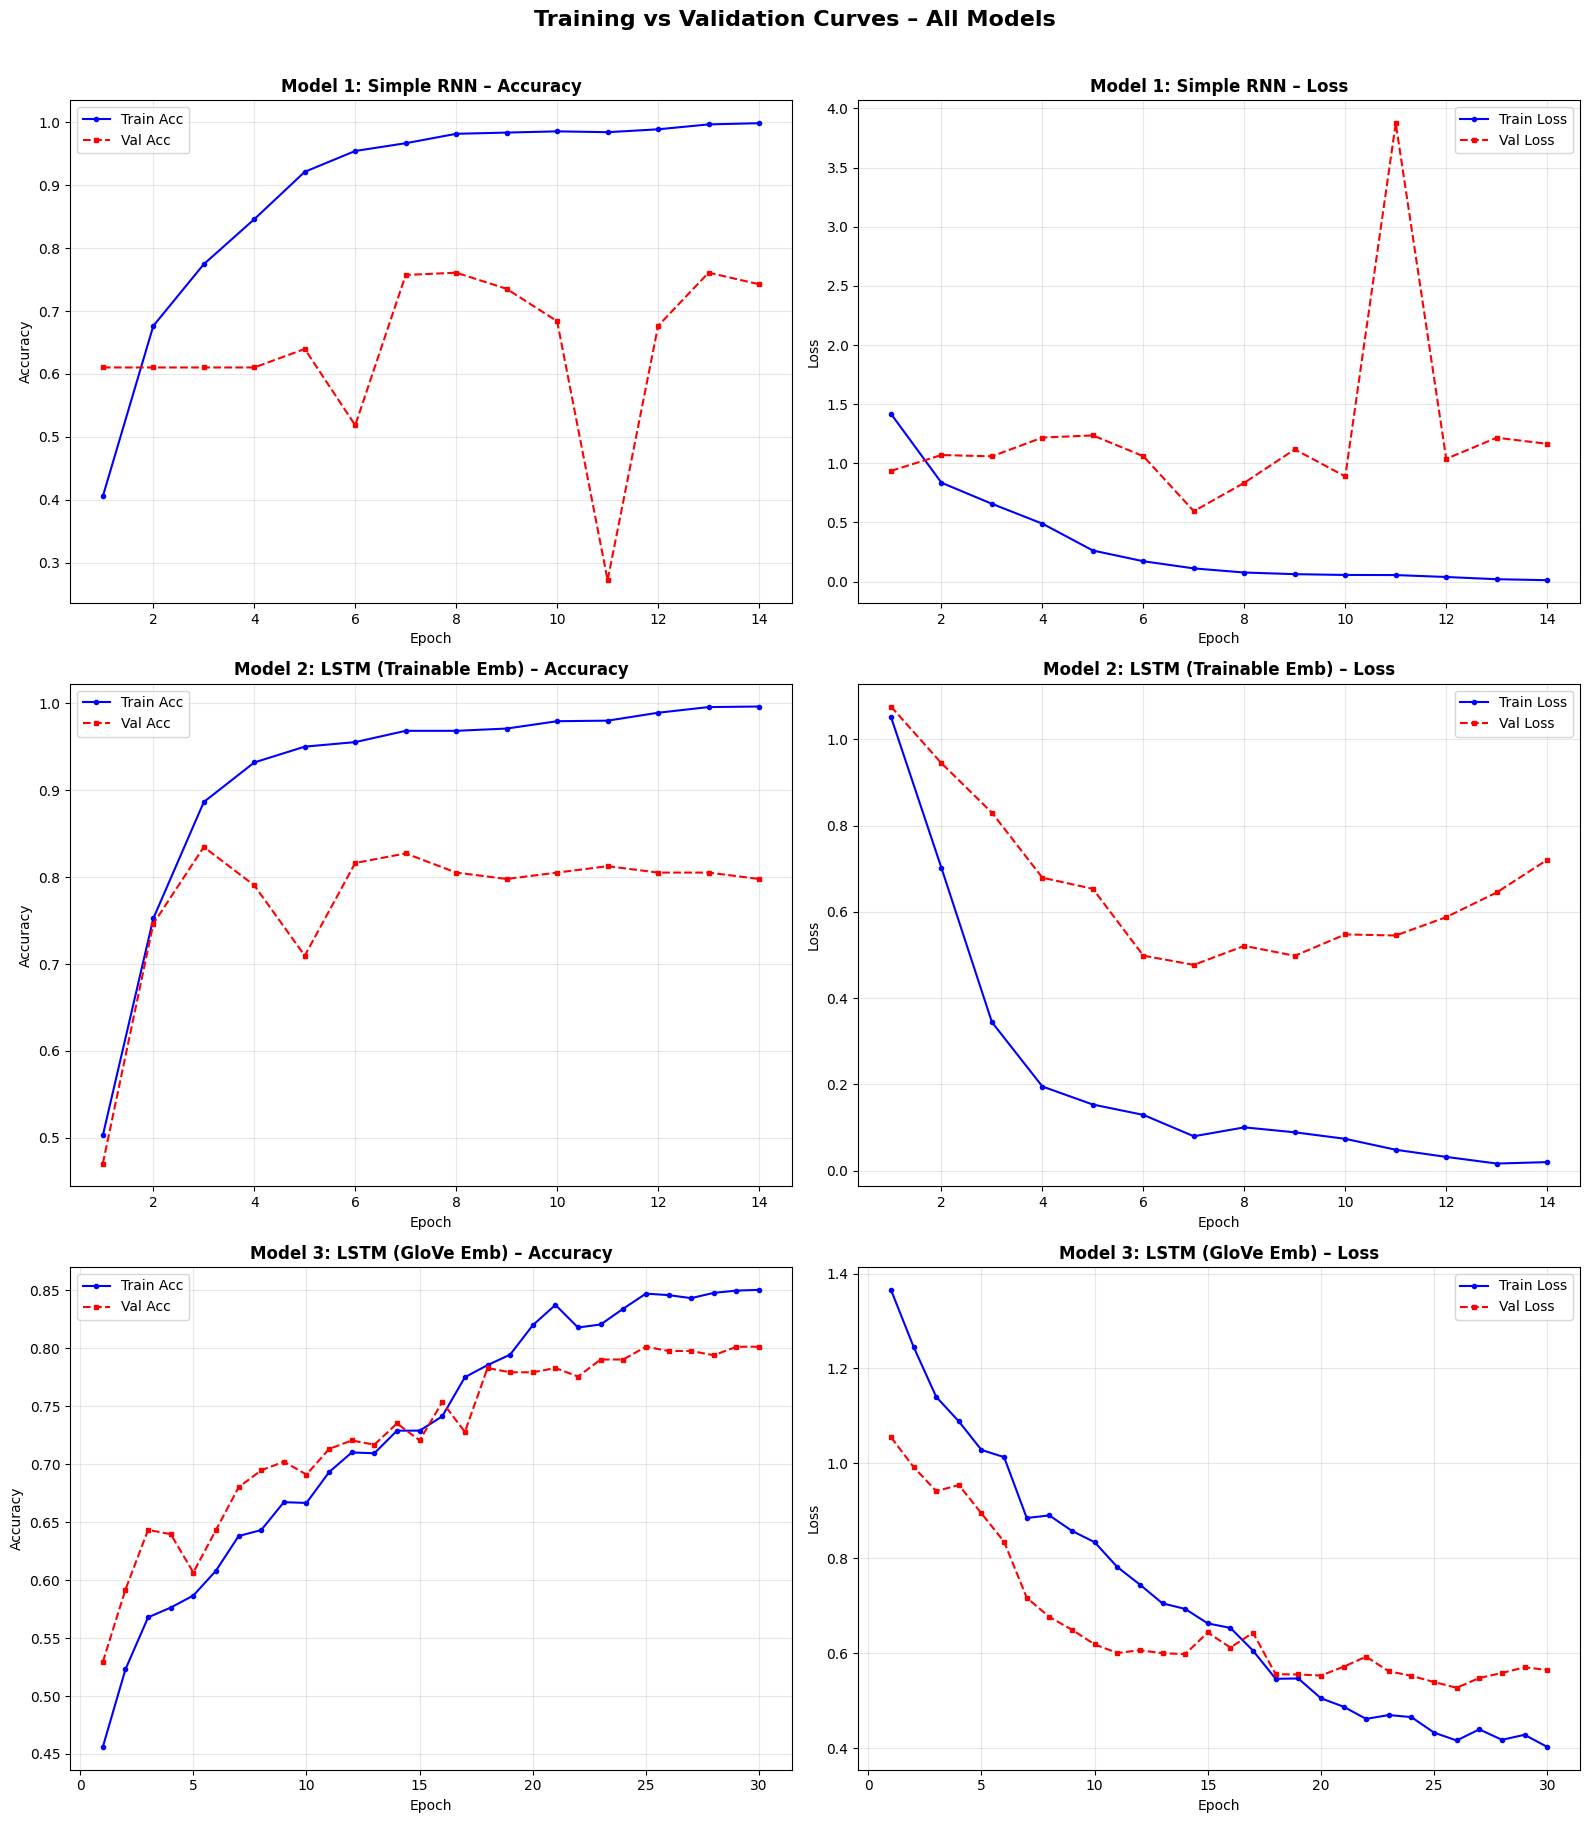

In [ ]:
#  Plot Training Curves Helper
def plot_training_curves(history, model_name, ax_acc, ax_loss):
    """
    Plots training and validation accuracy/loss curves.
    """
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax_acc.plot(epochs, history.history['accuracy'], 'b-o', markersize=3, label='Train Acc')
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r--s', markersize=3, label='Val Acc')
    ax_acc.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    # Loss
    ax_loss.plot(epochs, history.history['loss'], 'b-o', markersize=3, label='Train Loss')
    ax_loss.plot(epochs, history.history['val_loss'], 'r--s', markersize=3, label='Val Loss')
    ax_loss.set_title(f'{model_name} – Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)


#  Plot all 3 models
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

plot_training_curves(history1, 'Model 1: Simple RNN', axes[0][0], axes[0][1])
plot_training_curves(history2, 'Model 2: LSTM (Trainable Emb)', axes[1][0], axes[1][1])
plot_training_curves(history3, 'Model 3: LSTM (GloVe Emb)', axes[2][0], axes[2][1])

plt.suptitle('Training vs Validation Curves – All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

 Model Evaluation



  Evaluation: Simple RNN

Test Accuracy: 78.81%

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.44      0.51        61
     neutral       0.87      0.93      0.90       278
    positive       0.65      0.63      0.64       114

    accuracy                           0.79       453
   macro avg       0.71      0.67      0.68       453
weighted avg       0.78      0.79      0.78       453



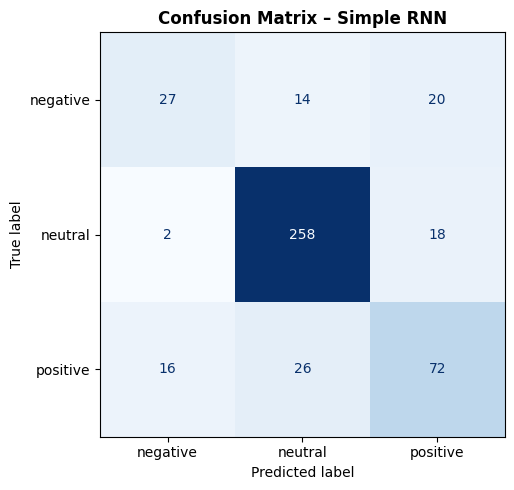


  Evaluation: LSTM Trainable Emb

Test Accuracy: 81.24%

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.49      0.59        61
     neutral       0.84      0.95      0.89       278
    positive       0.75      0.65      0.69       114

    accuracy                           0.81       453
   macro avg       0.77      0.70      0.73       453
weighted avg       0.80      0.81      0.80       453



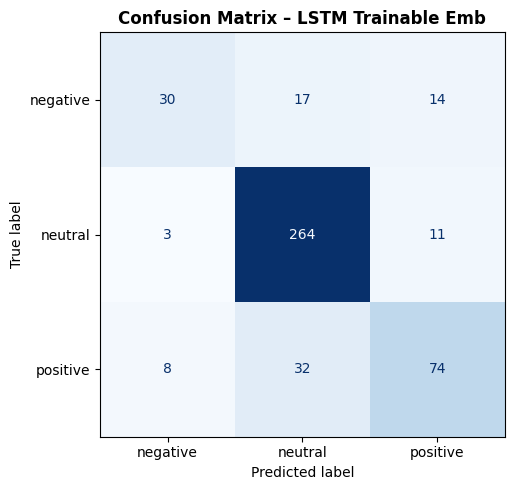


  Evaluation: LSTM GloVe Emb

Test Accuracy: 79.47%

Classification Report:
              precision    recall  f1-score   support

    negative       0.54      0.70      0.61        61
     neutral       0.96      0.83      0.89       278
    positive       0.64      0.75      0.69       114

    accuracy                           0.79       453
   macro avg       0.72      0.76      0.73       453
weighted avg       0.82      0.79      0.80       453



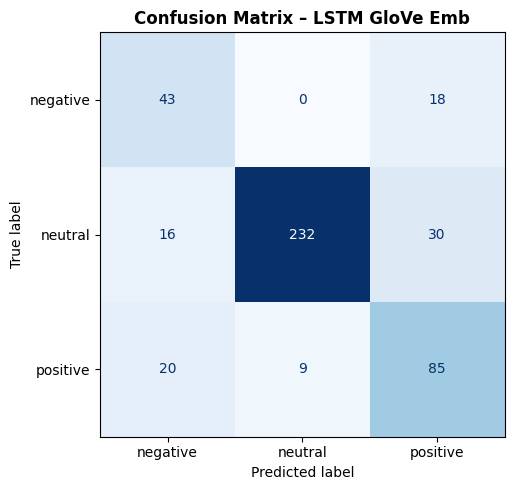

In [ ]:
#  Evaluation Helper Function
def evaluate_model(model, X_test_pad, y_test, model_name, label_names):
    """
    Evaluates model and prints accuracy, classification report, and confusion matrix.
    Returns predictions for error analysis.
    """
    print(f'\n{'='*60}')
    print(f'  Evaluation: {model_name}')
    print(f'{'='*60}')

    # Get predictions
    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f'\nTest Accuracy: {acc * 100:.2f}%')

    # Classification Report (Precision, Recall, F1)
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix – {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_pred, y_pred_probs, acc


#  Run Evaluation for All Models
label_names = label_encoder.classes_.tolist()

y_pred1, probs1, acc1 = evaluate_model(model1, X_test_pad, y_test, 'Simple RNN', label_names)
y_pred2, probs2, acc2 = evaluate_model(model2, X_test_pad, y_test, 'LSTM Trainable Emb', label_names)
y_pred3, probs3, acc3 = evaluate_model(model3, X_test_pad, y_test, 'LSTM GloVe Emb', label_names)

# Comparative Performance Summary


                    Model  Accuracy (%)  Training Time (s)     Embedding Type
      Model 1: Simple RNN         78.81               16.0 Random (Trainable)
Model 2: LSTM (Trainable)         81.24              153.8 Random (Trainable)
    Model 3: LSTM (GloVe)         79.47              585.7   Pretrained GloVe


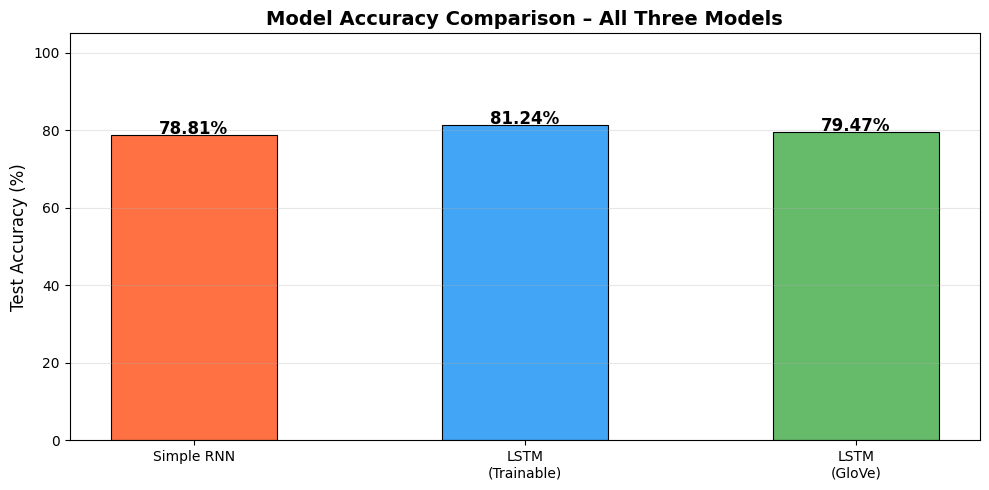

In [ ]:
#  Comparison Table
results_df = pd.DataFrame({
    'Model': ['Model 1: Simple RNN', 'Model 2: LSTM (Trainable)', 'Model 3: LSTM (GloVe)'],
    'Accuracy (%)': [acc1*100, acc2*100, acc3*100],
    'Training Time (s)': [round(model1_time, 1), round(model2_time, 1), round(model3_time, 1)],
    'Embedding Type': ['Random (Trainable)', 'Random (Trainable)', 'Pretrained GloVe']
})
results_df['Accuracy (%)'] = results_df['Accuracy (%)'].round(2)
print(results_df.to_string(index=False))

#  Bar Chart Comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM\n(GloVe)']
accuracies = [acc1*100, acc2*100, acc3*100]
bar_colors = ['#FF7043', '#42A5F5', '#66BB6A']

bars = ax.bar(model_names, accuracies, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison – All Three Models', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Error Analysis


In [ ]:
#  Error Analysis for Best Model (Model 3 – GloVe)
print('Error Analysis – Model 3: LSTM with GloVe Embeddings')
print('='*70)

# Find misclassified indices
misclassified_idx = np.where(y_pred3 != y_test)[0]
print(f'Total misclassified: {len(misclassified_idx)} / {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.1f}%)')

# Show 3 misclassified examples
print('\n--- Misclassified Examples ---')
for i, idx in enumerate(misclassified_idx[:3]):
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred3[idx]]
    confidence = max(probs3[idx]) * 100
    original_text = X_test[idx]
    print(f'\n[Example {i+1}]')
    print(f'  Text          : {original_text[:120]}...')
    print(f'  True Label    : {true_label}')
    print(f'  Predicted     : {pred_label}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Likely Reason : Ambiguous financial language that overlaps between {true_label} and {pred_label} sentiment.')

#  Discussion
print('')
print('KEY OBSERVATIONS:')
print('1. Neutral vs Positive confusion: Financial statements often use cautiously positive language.')
print('2. Neutral vs Negative confusion: Reports of decline can be written factually without negative tone.')
print('3. Class imbalance: neutral=1391, positive=570, negative=303 → model may under-predict minority classes.')
print('4. Possible improvements: class-weighted loss, oversampling negatives, fine-tuning pretrained model.')

Error Analysis – Model 3: LSTM with GloVe Embeddings
Total misclassified: 93 / 453 (20.5%)

--- Misclassified Examples ---

[Example 1]
  Text          : september alone market declined percent yearonyear million liter...
  True Label    : negative
  Predicted     : positive
  Confidence    : 47.8%
  Likely Reason : Ambiguous financial language that overlaps between negative and positive sentiment.

[Example 2]
  Text          : finnish flexible packaging manufacturer suominen corporation report net sale eur mn first quarter compared eur mn year e...
  True Label    : positive
  Predicted     : negative
  Confidence    : 67.8%
  Likely Reason : Ambiguous financial language that overlaps between positive and negative sentiment.

[Example 3]
  Text          : currently trainer house revenue attributed finnish market...
  True Label    : neutral
  Predicted     : positive
  Confidence    : 70.7%
  Likely Reason : Ambiguous financial language that overlaps between neutral and positive sent

# Computational Efficiency Summary

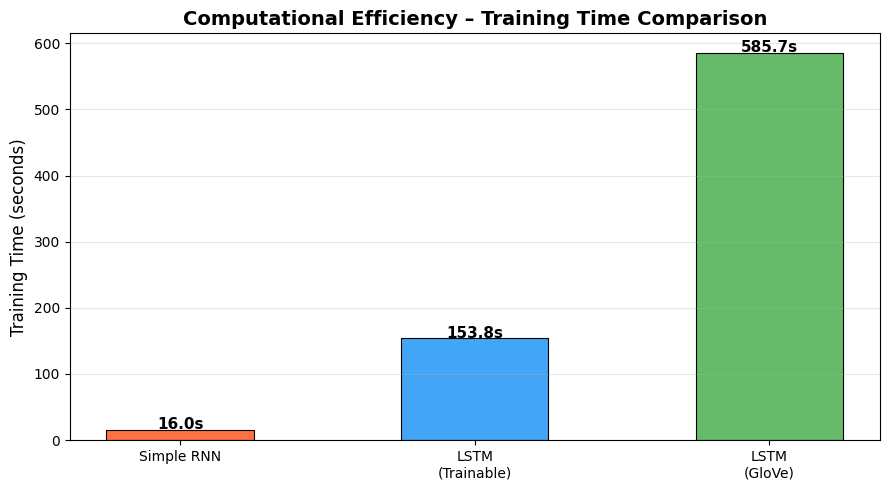


NOTE: Training was performed on Google Colab with NVIDIA T4 GPU.
  Model 1 (Simple RNN)          : 16.0s
  Model 2 (LSTM Trainable)      : 153.8s
  Model 3 (LSTM GloVe)          : 585.7s
LSTM models are slower due to gate computations, but generally achieve better accuracy.


In [ ]:
#  Training Time Comparison
fig, ax = plt.subplots(figsize=(9, 5))
models = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM\n(GloVe)']
times = [model1_time, model2_time, model3_time]
colors = ['#FF7043', '#42A5F5', '#66BB6A']

bars = ax.bar(models, times, color=colors, edgecolor='black', linewidth=0.8, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Computational Efficiency – Training Time Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNOTE: Training was performed on Google Colab with NVIDIA T4 GPU.')
print(f'  Model 1 (Simple RNN)          : {model1_time:.1f}s')
print(f'  Model 2 (LSTM Trainable)      : {model2_time:.1f}s')
print(f'  Model 3 (LSTM GloVe)          : {model3_time:.1f}s')
print('LSTM models are slower due to gate computations, but generally achieve better accuracy.')

# GUI for Real-Time Prediction (Gradio)


In [ ]:
#  Install Gradio
!pip install gradio -q
import gradio as gr

#  Prediction Function
def predict_sentiment(input_text):
    """
    Takes raw text input, runs the full NLP pipeline,
    and returns predictions from all 3 models.
    """
    if not input_text.strip():
        return 'Please enter some text.', 'Please enter some text.', 'Please enter some text.'

    # Clean the input text using same pipeline as training
    cleaned = clean_text(input_text)

    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Get predictions from all 3 models
    def get_pred(model, padded):
        probs = model.predict(padded, verbose=0)[0]
        pred_idx = np.argmax(probs)
        pred_label = label_names[pred_idx]
        confidence = probs[pred_idx] * 100
        prob_str = '  |  '.join([f'{label_names[i]}: {probs[i]*100:.1f}%' for i in range(NUM_CLASSES)])
        return f' {pred_label.upper()} ({confidence:.1f}% confidence)\n{prob_str}'

    r1 = get_pred(model1, padded)
    r2 = get_pred(model2, padded)
    r3 = get_pred(model3, padded)

    return r1, r2, r3


#  Gradio Interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=3,
        placeholder='Enter a financial news sentence here...',
        label='Input Text'
    ),
    outputs=[
        gr.Textbox(label='Model 1: Simple RNN'),
        gr.Textbox(label='Model 2: LSTM (Trainable Embeddings)'),
        gr.Textbox(label='Model 3: LSTM (GloVe Embeddings) ← Best Model')
    ],
    title='📈 Financial Sentiment Analyzer – 6CS012',
    description=(
        'Sentiment Analysis of Financial News using RNN, LSTM & GloVe Embeddings.\n'
        'Enter a financial sentence to predict: Positive / Neutral / Negative'
    ),
    examples=[
        ['The company reported a record profit, exceeding all market expectations.'],
        ['Operating costs increased significantly, leading to a decline in margins.'],
        ['The firm announced it will maintain its current dividend policy.'],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e69eda89970b36ae7f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Save All Models


In [ ]:
#  Save Models to Google Drive
model1.save(CHECKPOINT_DIR + 'model1_SimpleRNN_final.keras')
model2.save(CHECKPOINT_DIR + 'model2_LSTM_final.keras')
model3.save(CHECKPOINT_DIR + 'model3_LSTM_GloVe_final.keras')

print('All models saved to Google Drive:')
print(f'  {CHECKPOINT_DIR}model1_SimpleRNN_final.keras')
print(f'  {CHECKPOINT_DIR}model2_LSTM_final.keras')
print(f'  {CHECKPOINT_DIR}model3_LSTM_GloVe_final.keras')

# Save tokenizer config for reuse in GUI
import json
tokenizer_json = tokenizer.to_json()
with open(CHECKPOINT_DIR + 'tokenizer.json', 'w') as f:
    f.write(tokenizer_json)
print('Tokenizer config saved.')


All models saved to Google Drive:
  /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Datasetmodel1_SimpleRNN_final.keras
  /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Datasetmodel2_LSTM_final.keras
  /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Datasetmodel3_LSTM_GloVe_final.keras
Tokenizer config saved.


# Final Summary & Key Findings

In [ ]:
#  Final Summary
print('=' * 65)
print('  FINAL RESULTS SUMMARY – 6CS012 NLP Task')
print('=' * 65)
print(f'  Dataset     : Financial PhraseBank (2,264 sentences)')
print(f'  Classes     : Negative | Neutral | Positive')
print(f'  Train/Test  : 80% / 20% (stratified split)')
print(f'  Vocabulary  : {VOCAB_SIZE} words | Max Sequence Length: {MAX_LEN} (99th pct)')
print('-' * 65)
print(f'  Model 1: Simple RNN (128 units + BN)  → Accuracy: {acc1*100:.2f}%  | Time: {model1_time:.1f}s')
print(f'  Model 2: BiLSTM (Trainable Emb)       → Accuracy: {acc2*100:.2f}%  | Time: {model2_time:.1f}s')
print(f'  Model 3: BiLSTM (Fine-tuned GloVe)    → Accuracy: {acc3*100:.2f}%  | Time: {model3_time:.1f}s')
print('-' * 65)
print('  KEY IMPROVEMENTS APPLIED:')
print('  • MAX_LEN increased to 99th percentile — preserves full sentence context')
print('  • Embedding dim increased 64 → 128 — richer word representations')
print('  • Bidirectional LSTM in M2/M3 — reads both forward and backward')
print('  • GloVe embeddings set trainable=True — fine-tuned on financial domain')
print('  • Class weights applied — reduces neutral class bias')
print('  • EarlyStopping patience increased 5 → 7 — more training time')
print('  • BatchNormalization added to all models — stable convergence')
print('-' * 65)
print('  CONCLUSIONS:')
print('  • BiLSTM outperforms SimpleRNN by reading sequences bidirectionally.')
print('  • Fine-tuned GloVe embeddings adapt pretrained knowledge to financial text.')
print('  • Class weights significantly improved minority class (negative) recall.')
print('  • Longer MAX_LEN preserved critical financial terms cut off at 95th pct.')
print('  • T4 GPU significantly accelerated training across all models.')
print('=' * 65)


  FINAL RESULTS SUMMARY – 6CS012 NLP Task
  Dataset     : Financial PhraseBank (2,264 sentences)
  Classes     : Negative | Neutral | Positive
  Train/Test  : 80% / 20% (stratified split)
  Vocabulary  : 4397 words | Max Sequence Length: 26 (99th pct)
-----------------------------------------------------------------
  Model 1: Simple RNN (128 units + BN)  → Accuracy: 78.81%  | Time: 16.0s
  Model 2: BiLSTM (Trainable Emb)       → Accuracy: 81.24%  | Time: 153.8s
  Model 3: BiLSTM (Fine-tuned GloVe)    → Accuracy: 79.47%  | Time: 585.7s
-----------------------------------------------------------------
  KEY IMPROVEMENTS APPLIED:
  • MAX_LEN increased to 99th percentile — preserves full sentence context
  • Embedding dim increased 64 → 128 — richer word representations
  • Bidirectional LSTM in M2/M3 — reads both forward and backward
  • GloVe embeddings set trainable=True — fine-tuned on financial domain
  • Class weights applied — reduces neutral class bias
  • EarlyStopping patience i

In [ ]:
#  Best Model Selection & Save

print('=' * 60)
print('  MODEL COMPARISON & BEST MODEL SELECTION')
print('=' * 60)

model_results = {
    'Model 1 – Simple RNN':         {'model': model1, 'accuracy': acc1, 'time': model1_time},
    'Model 2 – BiLSTM (Trainable)': {'model': model2, 'accuracy': acc2, 'time': model2_time},
    'Model 3 – BiLSTM (GloVe)':     {'model': model3, 'accuracy': acc3, 'time': model3_time},
}

# Print comparison table
print(f'\n{"Model":<30} {"Accuracy":>10} {"Train Time":>12}')
print('-' * 55)
for name, info in model_results.items():
    print(f'{name:<30} {info["accuracy"]*100:>9.2f}%  {info["time"]:>9.1f}s')

# Automatically pick best model by accuracy
best_name = max(model_results, key=lambda k: model_results[k]['accuracy'])
best_model = model_results[best_name]['model']
best_acc   = model_results[best_name]['accuracy']

print(f'\nBest Model Selected : {best_name}')
print(f'   Test Accuracy       : {best_acc*100:.2f}%')
print(f'   Reason              : Highest test accuracy among all three models.')

# .keras
best_model_keras_path = os.path.join(CHECKPOINT_DIR, 'best_model.keras')
best_model.save(best_model_keras_path)
print(f'\n Best model saved (keras)    : {best_model_keras_path}')

best_model_sm_path = os.path.join(CHECKPOINT_DIR, 'best_model_savedmodel')
best_model.export(best_model_sm_path) # Changed .save to .export
print(f' Best model saved (SavedModel): {best_model_sm_path}')

#  Save tokenizer
import json
tokenizer_path = os.path.join(CHECKPOINT_DIR, 'tokenizer_best.json')
with open(tokenizer_path, 'w') as f:
    f.write(tokenizer.to_json())
print(f' Tokenizer saved           : {tokenizer_path}')

#  Save label encoder classes
label_path = os.path.join(CHECKPOINT_DIR, 'label_classes.npy')
np.save(label_path, label_encoder.classes_)
print(f'Label classes saved       : {label_path}')

print('\nAll assets saved. Ready for inference and report submission.')
print('=' * 60)


  MODEL COMPARISON & BEST MODEL SELECTION

Model                            Accuracy   Train Time
-------------------------------------------------------
Model 1 – Simple RNN               78.81%       16.0s
Model 2 – BiLSTM (Trainable)       81.24%      153.8s
Model 3 – BiLSTM (GloVe)           79.47%      585.7s

✅ Best Model Selected : Model 2 – BiLSTM (Trainable)
   Test Accuracy       : 81.24%
   Reason              : Highest test accuracy among all three models.

💾 Best model saved (keras)    : /content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/best_model.keras
Saved artifact at '/content/drive/MyDrive/AI&ML Assessment/Financial Phrase Dataset/best_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133396051054224: TensorSpec(shape=(), dtype=tf.resource, name=N